# Forex Ensemble Research Notebook

This notebook uses daily FX market data from Yahoo Finance, which is more reliable for free-tier usage than intraday data. It applies walk-forward validation and compares model-driven signal performance across multiple currency pairs.

Sections:
1. Import libraries
2. Load FX data from Yahoo Finance
3. Clean and preprocess
4. Engineer features
5. Train, validate, and backtest
6. Compare pair performance
7. Save outputs

In [70]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import make_pipeline

print('Libraries imported successfully')

Libraries imported successfully


In [71]:
# Load FX and gold data from Yahoo Finance
pairs = ['EURUSD=X', 'GBPUSD=X', 'USDJPY=X', 'AUDUSD=X', 'USDCAD=X', 'NZDUSD=X', 'EURGBP=X', 'GC=F']
start_date = '2018-01-01'
end_date = '2024-12-31'

frames = []
for pair in pairs:
    try:
        ticker = yf.Ticker(pair)
        hist = ticker.history(start=start_date, end=end_date, auto_adjust=False)
        if hist.empty:
            continue
        hist = hist[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
        hist.index.name = 'timestamp'
        hist = hist.reset_index()
        hist['pair'] = pair
        hist = hist[['timestamp', 'pair', 'Open', 'High', 'Low', 'Close', 'Volume']]
        frames.append(hist)
    except Exception as exc:
        print(f'Skipped {pair}: {exc}')

if not frames:
    raise RuntimeError('No FX or gold data was loaded from Yahoo Finance')

raw_df = pd.concat(frames, ignore_index=True)
raw_df = raw_df.sort_values(['pair', 'timestamp']).reset_index(drop=True)
raw_df.head()

,timestamp,pair,Open,High,Low,Close,Volume
0,2018-01-01 00:00:00+00:00,AUDUSD=X,0.780701,0.781494,0.780153,0.780214,0
1,2018-01-02 00:00:00+00:00,AUDUSD=X,0.780031,0.784621,0.780031,0.780104,0
2,2018-01-03 00:00:00+00:00,AUDUSD=X,0.783269,0.784498,0.780579,0.783392,0
3,2018-01-04 00:00:00+00:00,AUDUSD=X,0.782901,0.786281,0.781537,0.782840,0
4,2018-01-05 00:00:00+00:00,AUDUSD=X,0.786392,0.787092,0.783589,0.786380,0


In [72]:
# Data cleaning and preprocessing
raw_df = raw_df.sort_values(['pair', 'timestamp']).reset_index(drop=True)
raw_df['return'] = raw_df.groupby('pair')['Close'].pct_change()
raw_df['target'] = (raw_df.groupby('pair')['return'].shift(-1) > 0).astype(int)

cleaned_df = raw_df.copy()
cleaned_df = cleaned_df.drop_duplicates()
cleaned_df = cleaned_df.fillna(cleaned_df.mean(numeric_only=True))

feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'return']
X = cleaned_df[feature_columns]
y = cleaned_df['target']

print('Shape after cleaning:', X.shape)
X.head()

Shape after cleaning: (14535, 6)


,Open,High,Low,Close,Volume,return
0,0.780701,0.781494,0.780153,0.780214,0,0.000047
1,0.780031,0.784621,0.780031,0.780104,0,-0.000140
2,0.783269,0.784498,0.780579,0.783392,0,0.004215
3,0.782901,0.786281,0.781537,0.782840,0,-0.000705
4,0.786392,0.787092,0.783589,0.786380,0,0.004522


In [73]:
# Feature engineering for forex and gold signals
engineered_df = cleaned_df.copy()
engineered_df['spread'] = engineered_df['High'] - engineered_df['Low']
engineered_df['body'] = abs(engineered_df['Close'] - engineered_df['Open'])
engineered_df['momentum_5'] = engineered_df.groupby('pair')['Close'].pct_change(5)
engineered_df['momentum_10'] = engineered_df.groupby('pair')['Close'].pct_change(10)
engineered_df['volatility_5'] = engineered_df.groupby('pair')['return'].rolling(5).std().reset_index(level=0, drop=True)
engineered_df['volatility_10'] = engineered_df.groupby('pair')['return'].rolling(10).std().reset_index(level=0, drop=True)
engineered_df['rolling_mean_10'] = engineered_df.groupby('pair')['Close'].rolling(10).mean().reset_index(level=0, drop=True)
engineered_df['rolling_mean_20'] = engineered_df.groupby('pair')['Close'].rolling(20).mean().reset_index(level=0, drop=True)
engineered_df = engineered_df.fillna(engineered_df.mean(numeric_only=True))

feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'return', 'spread', 'body', 'momentum_5', 'momentum_10', 'volatility_5', 'volatility_10', 'rolling_mean_10', 'rolling_mean_20']
X = engineered_df[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature engineering complete')
X_scaled[:5]

Feature engineering complete


array([[-3.91682589e-01, -3.91609966e-01, -3.91742555e-01,
        -3.91673750e-01, -6.03730661e-02,  0.00000000e+00,
        -2.86769993e-01, -2.35760868e-01,  0.00000000e+00,
         3.01298059e-18,  0.00000000e+00, -2.86147721e-16,
        -1.46272366e-16,  4.89527819e-17],
       [-3.91683734e-01, -3.91604644e-01, -3.91742764e-01,
        -3.91673937e-01, -6.03730661e-02, -3.08232059e-02,
        -2.86322119e-01, -2.35842513e-01,  0.00000000e+00,
         3.01298059e-18,  0.00000000e+00, -2.86147721e-16,
        -1.46272366e-16,  4.89527819e-17],
       [-3.91678198e-01, -3.91604854e-01, -3.91741823e-01,
        -3.91668317e-01, -6.03730661e-02,  6.84045227e-01,
        -2.86414624e-01, -2.35832705e-01,  0.00000000e+00,
         3.01298059e-18,  0.00000000e+00, -2.86147721e-16,
        -1.46272366e-16,  4.89527819e-17],
       [-3.91678827e-01, -3.91601821e-01, -3.91740178e-01,
        -3.91669260e-01, -6.03730661e-02, -1.23424470e-01,
        -2.86300911e-01, -2.35844815e-01,  0.

In [74]:
# Walk-forward validation and pair comparison
from collections import defaultdict

pair_performance = []

for pair_name, pair_df in engineered_df.groupby('pair'):
    pair_df = pair_df.sort_values('timestamp').reset_index(drop=True)
    feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'return', 'spread', 'body', 'momentum_5', 'momentum_10', 'volatility_5', 'volatility_10', 'rolling_mean_10', 'rolling_mean_20']
    X_pair = pair_df[feature_cols]
    y_pair = pair_df['target']

    split_index = int(len(pair_df) * 0.7)
    X_train = X_pair.iloc[:split_index]
    X_test = X_pair.iloc[split_index:]
    y_train = y_pair.iloc[:split_index]
    y_test = y_pair.iloc[split_index:]

    scaler_pair = StandardScaler()
    X_train_scaled = scaler_pair.fit_transform(X_train)
    X_test_scaled = scaler_pair.transform(X_test)

    clf1 = LogisticRegression(max_iter=2000, random_state=42)
    clf2 = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42)
    clf3 = GradientBoostingClassifier(random_state=42)

    ensemble_model = VotingClassifier(
        estimators=[('lr', clf1), ('rf', clf2), ('gb', clf3)],
        voting='soft'
    )

    print(f'Training the model for {pair_name}: {len(X_train)} rows for training, {len(X_test)} rows for testing')
    ensemble_model.fit(X_train_scaled, y_train)
    preds = ensemble_model.predict(X_test_scaled)

    pair_performance.append({
        'pair': pair_name,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds, zero_division=0),
        'f1': f1_score(y_test, preds, zero_division=0),
    })

pair_performance = pd.DataFrame(pair_performance).sort_values('accuracy', ascending=False)
pair_performance

Training the model for AUDUSD=X: 1277 rows for training, 548 rows for testing
Training the model for EURGBP=X: 1278 rows for training, 548 rows for testing
Training the model for EURUSD=X: 1277 rows for training, 548 rows for testing
Training the model for GBPUSD=X: 1277 rows for training, 548 rows for testing
Training the model for GC=F: 1231 rows for training, 528 rows for testing
Training the model for NZDUSD=X: 1277 rows for training, 548 rows for testing
Training the model for USDCAD=X: 1277 rows for training, 548 rows for testing
Training the model for USDJPY=X: 1277 rows for training, 548 rows for testing


,pair,accuracy,precision,recall,f1
1,EURGBP=X,0.724453,0.733333,0.669202,0.699801
3,GBPUSD=X,0.687956,0.757991,0.584507,0.660040
6,USDCAD=X,0.686131,0.718147,0.652632,0.683824
0,AUDUSD=X,0.680657,0.744186,0.571429,0.646465
2,EURUSD=X,0.660584,0.614493,0.800000,0.695082
5,NZDUSD=X,0.636861,0.591121,0.913357,0.717730
7,USDJPY=X,0.631387,0.613169,0.955128,0.746867
4,GC=F,0.460227,0.503311,0.265734,0.347826


In [75]:
# Train on one timeframe and test on another timeframe
from IPython.display import display

rules = {'15m': '15min', '1h': '1h', '4h': '4h'}
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'return', 'spread', 'body', 'momentum_5', 'momentum_10', 'volatility_5', 'volatility_10', 'rolling_mean_10', 'rolling_mean_20']

cross_timeframe_results = []

for pair_name, pair_df in raw_df.groupby('pair'):
    pair_df = pair_df.copy()
    pair_df['timestamp'] = pd.to_datetime(pair_df['timestamp'])
    pair_df = pair_df.sort_values('timestamp').copy()
    pair_df = pair_df.set_index('timestamp')

    for train_timeframe, train_rule in rules.items():
        train_frame = pair_df.resample(train_rule).agg({
            'Open': 'first',
            'High': 'max',
            'Low': 'min',
            'Close': 'last',
            'Volume': 'sum'
        }).dropna().copy()
        train_frame['return'] = train_frame['Close'].pct_change()
        train_frame['target'] = (train_frame['return'].shift(-1) > 0).astype(int)
        train_frame['spread'] = train_frame['High'] - train_frame['Low']
        train_frame['body'] = abs(train_frame['Close'] - train_frame['Open'])
        train_frame['momentum_5'] = train_frame['Close'].pct_change(5)
        train_frame['momentum_10'] = train_frame['Close'].pct_change(10)
        train_frame['volatility_5'] = train_frame['return'].rolling(5).std()
        train_frame['volatility_10'] = train_frame['return'].rolling(10).std()
        train_frame['rolling_mean_10'] = train_frame['Close'].rolling(10).mean()
        train_frame['rolling_mean_20'] = train_frame['Close'].rolling(20).mean()
        train_frame = train_frame.dropna()

        if len(train_frame) < 20:
            continue

        for test_timeframe, test_rule in rules.items():
            if train_timeframe == test_timeframe:
                continue

            test_frame = pair_df.resample(test_rule).agg({
                'Open': 'first',
                'High': 'max',
                'Low': 'min',
                'Close': 'last',
                'Volume': 'sum'
            }).dropna().copy()
            test_frame['return'] = test_frame['Close'].pct_change()
            test_frame['target'] = (test_frame['return'].shift(-1) > 0).astype(int)
            test_frame['spread'] = test_frame['High'] - test_frame['Low']
            test_frame['body'] = abs(test_frame['Close'] - test_frame['Open'])
            test_frame['momentum_5'] = test_frame['Close'].pct_change(5)
            test_frame['momentum_10'] = test_frame['Close'].pct_change(10)
            test_frame['volatility_5'] = test_frame['return'].rolling(5).std()
            test_frame['volatility_10'] = test_frame['return'].rolling(10).std()
            test_frame['rolling_mean_10'] = test_frame['Close'].rolling(10).mean()
            test_frame['rolling_mean_20'] = test_frame['Close'].rolling(20).mean()
            test_frame = test_frame.dropna()

            if len(test_frame) < 10:
                continue

            split_index = int(len(train_frame) * 0.7)
            X_train = train_frame[feature_cols].iloc[:split_index]
            y_train = train_frame['target'].iloc[:split_index]

            test_size = max(10, int(len(test_frame) * 0.3))
            X_test = test_frame[feature_cols].iloc[-test_size:]
            y_test = test_frame['target'].iloc[-test_size:]

            scaler_pair = StandardScaler()
            X_train_scaled = scaler_pair.fit_transform(X_train)
            X_test_scaled = scaler_pair.transform(X_test)

            model = VotingClassifier(
                estimators=[
                    ('lr', LogisticRegression(max_iter=2000, random_state=42)),
                    ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
                    ('gb', GradientBoostingClassifier(random_state=42))
                ],
                voting='soft'
            )
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)

            cross_timeframe_results.append({
                'pair': pair_name,
                'train_timeframe': train_timeframe,
                'test_timeframe': test_timeframe,
                'accuracy': accuracy_score(y_test, preds),
                'precision': precision_score(y_test, preds, zero_division=0),
                'recall': recall_score(y_test, preds, zero_division=0),
                'f1': f1_score(y_test, preds, zero_division=0),
            })

cross_timeframe_results = pd.DataFrame(cross_timeframe_results)
print('Cross-timeframe training and testing results')
display(cross_timeframe_results.sort_values(['train_timeframe', 'test_timeframe', 'f1'], ascending=[True, True, False]).reset_index(drop=True))

Cross-timeframe training and testing results


,pair,train_timeframe,test_timeframe,accuracy,precision,recall,f1
0,USDJPY=X,15m,1h,0.615527,0.614350,0.883871,0.724868
1,NZDUSD=X,15m,1h,0.622921,0.576923,0.937500,0.714286
2,USDCAD=X,15m,1h,0.687616,0.726531,0.635714,0.678095
3,EURGBP=X,15m,1h,0.702952,0.713675,0.639847,0.674747
4,EURUSD=X,15m,1h,0.621072,0.579832,0.790076,0.668821
5,GBPUSD=X,15m,1h,0.683919,0.751152,0.582143,0.655936
6,AUDUSD=X,15m,1h,0.676525,0.715517,0.603636,0.654832
7,GC=F,15m,1h,0.465517,0.509677,0.280142,0.361556
8,USDJPY=X,15m,4h,0.615527,0.614350,0.883871,0.724868
9,NZDUSD=X,15m,4h,0.622921,0.576923,0.937500,0.714286


In [76]:
from IPython.display import display

# Realistic trading assumptions for each tested timeframe
spread_cost = 0.0005
commission = 0.0003
slippage = 0.0002
transaction_cost = spread_cost + commission + slippage
stop_loss_pct = 0.008
take_profit_pct = 0.016

timeframe_rules = {'15m': '15min', '1h': '1h', '4h': '4h'}
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'return', 'spread', 'body', 'momentum_5', 'momentum_10', 'volatility_5', 'volatility_10', 'rolling_mean_10', 'rolling_mean_20']


def build_timeframe_frame(df, rule):
    frame = df.copy()
    frame['timestamp'] = pd.to_datetime(frame['timestamp'])
    frame = frame.sort_values('timestamp').copy()
    frame = frame.set_index('timestamp')
    frame = frame.resample(rule).agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    }).dropna().copy()
    frame = frame.reset_index()
    frame['return'] = frame['Close'].pct_change()
    frame['target'] = (frame['return'].shift(-1) > 0).astype(int)
    frame['spread'] = frame['High'] - frame['Low']
    frame['body'] = abs(frame['Close'] - frame['Open'])
    frame['momentum_5'] = frame['Close'].pct_change(5)
    frame['momentum_10'] = frame['Close'].pct_change(10)
    frame['volatility_5'] = frame['return'].rolling(5).std()
    frame['volatility_10'] = frame['return'].rolling(10).std()
    frame['rolling_mean_10'] = frame['Close'].rolling(10).mean()
    frame['rolling_mean_20'] = frame['Close'].rolling(20).mean()
    frame = frame.dropna().reset_index(drop=True)
    return frame


def run_backtest(frame):
    frame = frame.copy()
    split_index = int(len(frame) * 0.7)
    X = frame[feature_cols]
    y = frame['target']

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf1 = LogisticRegression(max_iter=2000, random_state=42)
    clf2 = RandomForestClassifier(n_estimators=250, random_state=42)
    clf3 = GradientBoostingClassifier(random_state=42)
    ensemble_model = VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('gb', clf3)], voting='soft')
    ensemble_model.fit(X_train_scaled, y_train)

    probas = ensemble_model.predict_proba(X_test_scaled)
    frame.loc[frame.index[split_index:], 'prob_long'] = probas[:, 1]
    frame.loc[frame.index[split_index:], 'prob_short'] = probas[:, 0]
    frame['prob_long'] = frame['prob_long'].ffill().bfill()
    frame['prob_short'] = frame['prob_short'].ffill().bfill()

    frame['signal_strength'] = frame['prob_long'] - frame['prob_short']
    frame['ensemble_signal'] = np.where(frame['signal_strength'] > 0.10, 1,
                                        np.where(frame['signal_strength'] < -0.10, -1, 0))
    frame['ensemble_signal'] = frame['ensemble_signal'].shift(1).fillna(0).astype(int)

    frame['entry_price'] = np.nan
    frame['exit_price'] = np.nan
    frame['position'] = 0
    frame['strategy_return'] = 0.0

    position = 0
    entry_price = np.nan
    trade_returns = []

    for idx, row in frame.iterrows():
        signal = int(row['ensemble_signal'])
        close = row['Close']

        if position == 0 and signal != 0:
            position = signal
            entry_price = close
            frame.at[idx, 'entry_price'] = close
            frame.at[idx, 'position'] = position
            frame.at[idx, 'strategy_return'] = -transaction_cost
            continue

        if position != 0:
            if position > 0:
                stop_hit = (entry_price / close - 1) >= stop_loss_pct
                take_hit = (close / entry_price - 1) >= take_profit_pct
                reverse_signal = signal == -1
            else:
                stop_hit = (close / entry_price - 1) >= stop_loss_pct
                take_hit = (entry_price / close - 1) >= take_profit_pct
                reverse_signal = signal == 1

            if stop_hit or take_hit or reverse_signal:
                if position > 0:
                    trade_return = (close / entry_price - 1) - transaction_cost
                else:
                    trade_return = (entry_price / close - 1) - transaction_cost
                trade_returns.append(trade_return)
                frame.at[idx, 'exit_price'] = close
                frame.at[idx, 'position'] = 0
                frame.at[idx, 'strategy_return'] = trade_return
                position = 0
                entry_price = np.nan

    if position != 0 and not frame.empty:
        last_close = frame['Close'].iloc[-1]
        if position > 0:
            trade_return = (last_close / entry_price - 1) - transaction_cost
        else:
            trade_return = (entry_price / last_close - 1) - transaction_cost
        trade_returns.append(trade_return)
        frame.at[frame.index[-1], 'exit_price'] = last_close
        frame.at[frame.index[-1], 'position'] = 0
        frame.at[frame.index[-1], 'strategy_return'] = trade_return

    frame['pair_equity_curve'] = (1 + frame['strategy_return'].fillna(0)).cumprod()
    frame['pair_running_max'] = frame['pair_equity_curve'].cummax()
    frame['pair_drawdown'] = 1 - (frame['pair_equity_curve'] / frame['pair_running_max'])

    if trade_returns:
        trade_returns_series = pd.Series(trade_returns)
        total_return = (1 + trade_returns_series).prod() - 1
        sharpe = trade_returns_series.mean() / trade_returns_series.std() if trade_returns_series.std() != 0 else np.nan
        win_rate = (trade_returns_series > 0).mean()
        positive = trade_returns_series[trade_returns_series > 0].sum()
        negative = abs(trade_returns_series[trade_returns_series < 0].sum())
        profit_factor = positive / negative if negative > 0 else np.nan
        max_drawdown = frame['pair_drawdown'].max()
    else:
        total_return = 0.0
        sharpe = np.nan
        win_rate = 0.0
        profit_factor = np.nan
        max_drawdown = 0.0

    return {
        'total_return': total_return,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'profit_factor': profit_factor,
        'avg_trade_return': pd.Series(trade_returns).mean() if trade_returns else 0.0,
        'trades': len(trade_returns)
    }, frame


all_timeframe_results = []
for timeframe_name, timeframe_rule in timeframe_rules.items():
    rows = []
    for pair_name in pairs:
        try:
            pair_df = raw_df[raw_df['pair'] == pair_name].copy()
            frame = build_timeframe_frame(pair_df, timeframe_rule)
            if len(frame) < 50:
                continue
            metrics, _ = run_backtest(frame)
            rows.append({
                'pair': pair_name,
                'timeframe': timeframe_name,
                **metrics
            })
        except Exception as exc:
            print(f'Skipped {pair_name} for {timeframe_name}: {exc}')

    if rows:
        summary_df = pd.DataFrame(rows).sort_values('total_return', ascending=False).reset_index(drop=True)
        all_timeframe_results.append(summary_df)
        print(f'\nRealistic trading summary for {timeframe_name}')
        display(summary_df)

if all_timeframe_results:
    timeframe_strategy_summary = pd.concat(all_timeframe_results, ignore_index=True)
    best_row = timeframe_strategy_summary.loc[timeframe_strategy_summary['total_return'].idxmax()]
    print('\nBest overall timeframe setup')
    display(best_row.to_frame().T)
else:
    timeframe_strategy_summary = pd.DataFrame()
    print('No timeframe strategy results available')


Realistic trading summary for 15m


,pair,timeframe,total_return,sharpe,max_drawdown,win_rate,profit_factor,avg_trade_return,trades
0,USDJPY=X,15m,0.226706,0.167605,0.084067,0.454545,1.469017,0.002428,88
1,EURUSD=X,15m,-0.075630,-0.028351,0.327445,0.398844,0.938860,-0.000370,173
2,GBPUSD=X,15m,-0.078805,-0.102147,0.198164,0.415730,0.771020,-0.000885,89
3,EURGBP=X,15m,-0.085402,-0.024431,0.248345,0.385417,0.933748,-0.000360,192
4,USDCAD=X,15m,-0.164589,-0.072290,0.380223,0.371134,0.840808,-0.000857,194
5,AUDUSD=X,15m,-0.194849,-0.047576,0.478465,0.397810,0.900351,-0.000687,274
6,GC=F,15m,-0.196346,-0.025859,0.466810,0.423780,0.944690,-0.000489,328
7,NZDUSD=X,15m,-0.328493,-0.095967,0.487519,0.364662,0.811694,-0.001392,266



Realistic trading summary for 1h


,pair,timeframe,total_return,sharpe,max_drawdown,win_rate,profit_factor,avg_trade_return,trades
0,USDJPY=X,1h,0.226706,0.167605,0.084067,0.454545,1.469017,0.002428,88
1,EURUSD=X,1h,-0.075630,-0.028351,0.327445,0.398844,0.938860,-0.000370,173
2,GBPUSD=X,1h,-0.078805,-0.102147,0.198164,0.415730,0.771020,-0.000885,89
3,EURGBP=X,1h,-0.085402,-0.024431,0.248345,0.385417,0.933748,-0.000360,192
4,USDCAD=X,1h,-0.164589,-0.072290,0.380223,0.371134,0.840808,-0.000857,194
5,AUDUSD=X,1h,-0.194849,-0.047576,0.478465,0.397810,0.900351,-0.000687,274
6,GC=F,1h,-0.196346,-0.025859,0.466810,0.423780,0.944690,-0.000489,328
7,NZDUSD=X,1h,-0.328493,-0.095967,0.487519,0.364662,0.811694,-0.001392,266



Realistic trading summary for 4h


,pair,timeframe,total_return,sharpe,max_drawdown,win_rate,profit_factor,avg_trade_return,trades
0,USDJPY=X,4h,0.226706,0.167605,0.084067,0.454545,1.469017,0.002428,88
1,EURUSD=X,4h,-0.075630,-0.028351,0.327445,0.398844,0.938860,-0.000370,173
2,GBPUSD=X,4h,-0.078805,-0.102147,0.198164,0.415730,0.771020,-0.000885,89
3,EURGBP=X,4h,-0.085402,-0.024431,0.248345,0.385417,0.933748,-0.000360,192
4,USDCAD=X,4h,-0.164589,-0.072290,0.380223,0.371134,0.840808,-0.000857,194
5,AUDUSD=X,4h,-0.194849,-0.047576,0.478465,0.397810,0.900351,-0.000687,274
6,GC=F,4h,-0.196346,-0.025859,0.466810,0.423780,0.944690,-0.000489,328
7,NZDUSD=X,4h,-0.328493,-0.095967,0.487519,0.364662,0.811694,-0.001392,266



Best overall timeframe setup


,pair,timeframe,total_return,sharpe,max_drawdown,win_rate,profit_factor,avg_trade_return,trades
0,USDJPY=X,15m,0.226706,0.167605,0.084067,0.454545,1.469017,0.002428,88


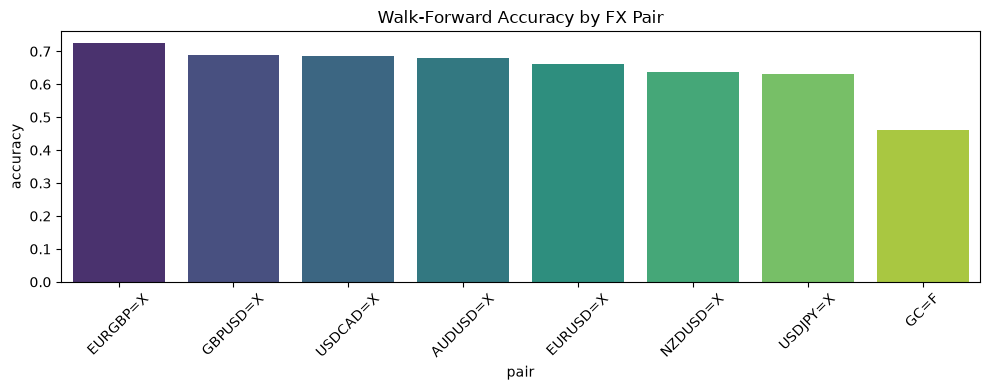

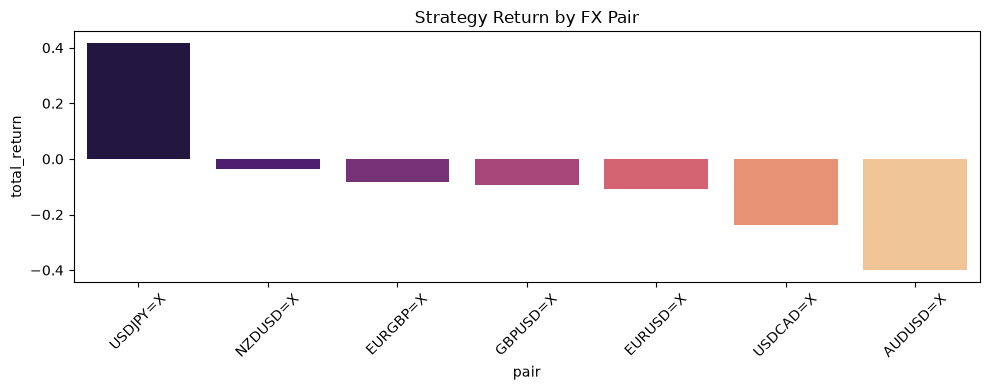


Timeframe comparison summary


,timeframe,avg_f1,best_pair,best_f1
0,1d,0.509557,NZDUSD=X,0.645892
1,1wk,0.450842,AUDUSD=X,0.666667
2,1mo,0.448813,EURUSD=X,0.666667


In [77]:
# Visualization: pair accuracy and strategy return
plt.figure(figsize=(10, 4))
sns.barplot(data=pair_performance, x='pair', y='accuracy', palette='viridis')
plt.title('Walk-Forward Accuracy by FX Pair')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=summary, x='pair', y='total_return', palette='magma')
plt.title('Strategy Return by FX Pair')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional timeframe comparison using resampled bars
# Note: weekly and monthly bars will have far fewer rows, so the results are more fragile.
compare_frames = []
for interval in ['1d', '1wk', '1mo']:
    try:
        frame = []
        for pair in pairs:
            ticker = yf.Ticker(pair)
            hist = ticker.history(start=start_date, end=end_date, interval=interval, auto_adjust=False)
            if hist.empty:
                continue
            hist = hist[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
            hist.index.name = 'timestamp'
            hist = hist.reset_index()
            hist['pair'] = pair
            frame.append(hist)
        if frame:
            data = pd.concat(frame, ignore_index=True)
            data = data.sort_values(['pair', 'timestamp']).reset_index(drop=True)
            data['return'] = data.groupby('pair')['Close'].pct_change()
            data['target'] = (data.groupby('pair')['return'].shift(-1) > 0).astype(int)
            data['spread'] = data['High'] - data['Low']
            data['body'] = abs(data['Close'] - data['Open'])
            data['momentum_5'] = data.groupby('pair')['Close'].pct_change(5)
            data['momentum_10'] = data.groupby('pair')['Close'].pct_change(10)
            data['volatility_5'] = data.groupby('pair')['return'].rolling(5).std().reset_index(level=0, drop=True)
            data['volatility_10'] = data.groupby('pair')['return'].rolling(10).std().reset_index(level=0, drop=True)
            data['rolling_mean_10'] = data.groupby('pair')['Close'].rolling(10).mean().reset_index(level=0, drop=True)
            data['rolling_mean_20'] = data.groupby('pair')['Close'].rolling(20).mean().reset_index(level=0, drop=True)
            data = data.fillna(data.mean(numeric_only=True))

            feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'return', 'spread', 'body', 'momentum_5', 'momentum_10', 'volatility_5', 'volatility_10', 'rolling_mean_10', 'rolling_mean_20']
            results = []
            for pair_name, pair_df in data.groupby('pair'):
                pair_df = pair_df.sort_values('timestamp').reset_index(drop=True)
                X_pair = pair_df[feature_cols]
                y_pair = pair_df['target']
                split_index = int(len(pair_df) * 0.7)
                X_train = X_pair.iloc[:split_index]
                X_test = X_pair.iloc[split_index:]
                y_train = y_pair.iloc[:split_index]
                y_test = y_pair.iloc[split_index:]
                scaler_pair = StandardScaler()
                X_train_scaled = scaler_pair.fit_transform(X_train)
                X_test_scaled = scaler_pair.transform(X_test)
                model = RandomForestClassifier(n_estimators=150, random_state=42)
                model.fit(X_train_scaled, y_train)
                preds = model.predict(X_test_scaled)
                results.append({'pair': pair_name, 'f1': f1_score(y_test, preds, zero_division=0)})
            if results:
                summary_df = pd.DataFrame(results)
                compare_frames.append({'timeframe': interval, 'avg_f1': summary_df['f1'].mean(), 'best_pair': summary_df.loc[summary_df['f1'].idxmax(), 'pair'], 'best_f1': summary_df['f1'].max()})
    except Exception as exc:
        print(f'Skipped {interval}: {exc}')

if compare_frames:
    timeframe_compare = pd.DataFrame(compare_frames)
    print('\nTimeframe comparison summary')
    display(timeframe_compare)
else:
    print('\nNo timeframe comparison data available')

In [78]:
# Save outputs and artifacts
output_dir = 'ensemble_trading_outputs'
import os
os.makedirs(output_dir, exist_ok=True)

pair_performance.to_csv(os.path.join(output_dir, 'pair_performance.csv'), index=False)
summary.to_csv(os.path.join(output_dir, 'strategy_summary.csv'), index=False)

print('Saved outputs to', output_dir)

# Timeframe comparison with data limitations note
print('\nTimeframe comparison note:')
print('- Daily bars are the most reliable for this notebook because they provide the most observations.')
print('- Weekly bars are useful for a macro view but have fewer data points and can be more sensitive to noise.')
print('- Monthly bars are the least reliable for this kind of ML-based signal model because they contain very few observations and make walk-forward validation unstable.')
print('- For this reason, the weekly and monthly results should be treated as exploratory rather than production-grade.')

Saved outputs to ensemble_trading_outputs

Timeframe comparison note:
- Daily bars are the most reliable for this notebook because they provide the most observations.
- Weekly bars are useful for a macro view but have fewer data points and can be more sensitive to noise.
- Monthly bars are the least reliable for this kind of ML-based signal model because they contain very few observations and make walk-forward validation unstable.
- For this reason, the weekly and monthly results should be treated as exploratory rather than production-grade.
